# Importing the libraries

In [376]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score 

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# import sys
# np.set_printoptions(threshold=sys.maxsize)
!pip install catboost
!pip install imblearn
!pip install tensorflow
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


ModuleNotFoundError: No module named 'catboost'

In [2]:
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 32.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Uninstalling threadpoolctl-2.2.0:
      Successfully uninstalled threadpoolctl-2.2.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2


# Importing the dataset

In [408]:
dataset = pd.read_csv('data.csv')


# Data exploataion 

 **Understanding the data**


 Process of analysing data to better understand it; it can also be used to prepare data for pre processing modelling. 

In [409]:
dataset.head()
#check the first 5 row of the data 

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Cleaning the data

**checking for null value**

In [402]:
dataset.isnull().sum()
#this function will retun columns and it null sum od it null value  

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [403]:
len(dataset.bmi)

5110

**Cleaning the data**

In [410]:
pp_data = dataset.copy()

le = LabelEncoder()
# le_cols = ['ever_married']
le_cols = ['gender', 'ever_married']
for col in le_cols:
    pp_data[col] = le.fit_transform(pp_data[col])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_cols = ['work_type', 'smoking_status', 'Residence_type']
encoded = pd.DataFrame(ohe.fit_transform(pp_data[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols))
encoded = encoded.drop('smoking_status_Unknown', axis=1)
pp_data = pd.concat([pp_data.drop(columns=ohe_cols), encoded], axis=1)

# MICE Imputation
imputer = IterativeImputer(max_iter=100, random_state=0)
pp_data = pd.DataFrame(imputer.fit_transform(pp_data), columns=pp_data.columns)

In [411]:
#dro all bmi rows with null values
# dataset = dataset.dropna()

# MICE Imputation
dataset['bmi'] = pp_data['bmi']

In [412]:
#drop the id colums 
dataset = dataset.drop('id', axis=1)
#drop the other in the gender 
dataset.drop(dataset.loc[dataset['gender']=='Other'].index, inplace=True)
dataset.age = dataset.age.round().astype('int')
dataset

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,31.124047,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80,1,0,Yes,Private,Urban,83.75,32.327535,never smoked,0
5106,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


# Data Preprocessing 

Slicing the dataset into dependent and independent variable

In [413]:

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values 

### Encoding categorical data with label encoder


label encoding is used for datapoint with only two values

In [414]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:,0] = le.fit_transform(X[:,0])
X[:,4] = le.fit_transform(X[:,4])
X[:,6] = le.fit_transform(X[:,6])


### One Hot Encoding the "Work_type and  "somke_status" column" column

In [415]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder',
OneHotEncoder(), [5,9])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

**Note** Onehotencoder is used one  datapoint with only two or more values which have numeric order

### Feature Selection 

In [416]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
test = SelectKBest(score_func=chi2, k='all')
fit = test.fit(X, y)
np.set_printoptions(precision=3)
print(fit.scores_)

X = fit.transform(X)

[3.149e-02 1.127e+00 3.108e-01 1.657e+01 3.112e+01 1.115e+01 1.768e+01
 5.575e-02 3.438e-01 2.469e-01 3.634e+03 7.542e+01 8.796e+01 2.060e+01
 5.971e-01 1.719e+03 1.720e+01]


In [417]:
#patient to be used for preditction 
patient = [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1, 67, 0, 1, 1, 1,228.69, 36.6]

## Splitting dateset

In [418]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, = train_test_split(X,y,test_size=0.2, random_state = 1)



In [419]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_train, y_train = sm.fit_resample(X_train, y_train)

**Handling imbalances data**

Verifying of  oversampling

In [420]:
np.unique(y_test, return_counts=True)

(array([0, 1]), array([962,  60]))

In [116]:
X_test

array([[0.0, 0.0, 1.0, ..., 1, 61.81, 25.5],
       [0.0, 0.0, 1.0, ..., 1, 89.7, 34.9],
       [0.0, 0.0, 0.0, ..., 1, 98.42, 36.4],
       ...,
       [0.0, 0.0, 0.0, ..., 1, 69.52, 24.2],
       [0.0, 0.0, 1.0, ..., 0, 97.5, 36.3],
       [0.0, 0.0, 1.0, ..., 1, 151.26, 20.6]], dtype=object)

In [34]:
X_train

array([[  0.   ,   0.   ,   1.   , ...,   1.   , 108.905,  35.728],
       [  0.   ,   0.   ,   0.   , ...,   0.521, 194.693,  30.021],
       [  0.   ,   0.   ,   1.   , ...,   0.   , 103.95 ,  31.732],
       ...,
       [  0.   ,   0.   ,   1.   , ...,   0.   ,  77.42 ,  26.1  ],
       [  0.   ,   0.   ,   0.342, ...,   1.   , 252.094,  29.679],
       [  1.   ,   0.   ,   0.   , ...,   0.   ,  94.61 ,  28.4  ]])

In [35]:
print(y_test)

[1 0 0 ... 1 1 1]


In [36]:
print(y_train)

[1 1 1 ... 0 1 0]


## Feature Scaling

In [421]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [422]:
print(X_test)

[[-0.432 -0.049 -1.269 ...  1.029 -1.014 -1.6  ]
 [-0.432 -0.049 -1.269 ...  1.029 -0.414 -0.949]
 [-0.432 -0.049 -1.269 ...  1.029 -0.431 -2.174]
 ...
 [-0.432 -0.049 -1.269 ...  1.029 -0.334 -0.949]
 [-0.432 -0.049 -1.269 ...  1.029 -0.394 -0.7  ]
 [-0.432 -0.049  0.922 ... -1.158  0.021  1.689]]


# Helper Functions

**Prediction Function**

In [244]:
#this function will be use to make predictions after models is train 
def prediction(classifier, X=X_test, y_true=y_test):
  y_pred = classifier.predict(X)

  print("Accuracy: {:.2f} %".format(accuracy_score(y_true, y_pred)*100))
  print("Precision: {:.2f} %".format(precision_score(y_true, y_pred) * 100))
  print("Recall: {:.2f} %".format(recall_score(y_true, y_pred) * 100))
  print("AUC: {:.2f} %".format(roc_auc_score(y_true, y_pred) * 100))
  print()

  # parameters = {
  #   'learning_rate': [0.001, 0.01, 0.03, 0.05, 0.1, 0.3],   # same as eta
  #   'max_depth': [3, 5, 7],
  #   'subsample': [0.8, 0.6, 0.5],
  #   'colsample_bytree': [0.8, 0.6, 0.5],
  #   'reg_lambda': [1, 5],   # L2 regularization
  #   'reg_alpha': [0, 1],    # L1 regularization
  #   'n_estimators': [100, 300]
  # }
     #this condition check if model accuracy is below 90% if so it apply tunning using gridsearch
  if accuracy_score(y_true, y_pred) < 1.1:
    print("MODELS RESULT IS BELOW 90% TUNNING WILL BE APPLIED ")
    classifier2 = grid_search_tunning(classifier, parameters)  # update classifier
    # y_pred = classifier.predict(X)  # re-predict with tuned model
  else: classifier2 = classifier;
    
  print()
  # Predicting the Test set results 
  print("Predicting the Test set results ")
  #matching all predtiction with true values this help eliminate overfiting
  print(np.concatenate((y_pred.reshape(len(y_pred),1), y_true.reshape(len(y_true),1)),1))
  print()
  print(f" Predicting for: ")
  #get the patient that will be used to make prediction from dataset
  print(dataset[:1])
  print(f" y_predicted :{classifier.predict(sc.transform([patient]))}")
  print("==================================================================")
  print()

  return classifier2




**Function for training models** 

In [245]:
def trainmodels(classifier, X_train, y_train):

  #this function takes the untrain models, train it then return the train model

  classifier.fit(X_train, y_train)
  #calling the prediction function to make predictions on the train models
  classifier2 = prediction(classifier, X_test, y_test)
  #making confusion matrix
  makin_confusion_matrix(classifier2)
  

  #this function return nthe train model.
  return classifier2


**Making the Confusion Matrix Function**

In [434]:
def makin_confusion_matrix(classifier,X=X_test):
  #this function takes train model and make matrix on it 
  print(X_test.size)
  y_pred = classifier.predict(X)
  print(y_pred.size)
  cm = confusion_matrix(y_test, y_pred)
  classifier_report=classification_report(y_test, y_pred )
  print()
  print("Making the Confusion Matrix")
  print("**************************")
  print("Accuracy: {:.2f} %".format(accuracy_score(y_test,y_pred)*100))
  print(cm)
  print("")
  print("")
  print("Accuracy repeort")
  print(classifier_report)
  

  


**Plot Confusion matrix function **

In [238]:
def plot_confusion_matrix(classifier, X=X_test):
  y_pred = classifier.predict(X)
  cm_map = sns.heatmap(confusion_matrix(y_test, y_pred),annot=True,cmap='OrRd', fmt='g')
  plt.show(cm_map)

**Function for app K-Fold cross validation**

In [239]:
def k_fold_cross_validation(classifier, X_train, y_train, cv:int):
  print("****************************************************")
  accuracies = cross_val_score(estimator =  classifier, X = X_train, y = y_train, cv = 15)
  print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
  print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))
  
  

**Function for Grid search fine tuning**

**Note:** tunning is only apply to models with accuracy below 90%

In [240]:
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
gs_results = pd.DataFrame();

def grid_search_tunning(classifier, parameters):
    global gs_results
    # Define multiple scoring metrics
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='binary'),
        'recall': make_scorer(recall_score, average='binary'),
        'f1': make_scorer(f1_score, average='binary'),
        'roc_auc': make_scorer(roc_auc_score)
    }

    print(parameters)
    # Run grid search with multiple metrics
    grid_search = GridSearchCV(
        estimator=classifier,
        param_grid=parameters,
        scoring=scoring,
        refit='accuracy',   # choose which metric to optimize
        verbose=1,
        cv=10,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    results = grid_search.cv_results_
    best_accuracy = grid_search.best_score_
    best_parameters = grid_search.best_params_
    print("Best Accuracy on Training: {:.2f} %".format(best_accuracy*100))
    print("Best Parameters:", best_parameters)
    
    # Build DataFrame with metrics
    metrics_df = pd.DataFrame({
        'accuracy': results['mean_test_accuracy'],
        'precision': results['mean_test_precision'],
        'recall': results['mean_test_recall'],
        'f1': results['mean_test_f1'],
        'roc_auc': results['mean_test_roc_auc']
    })
    
    # Expand params dict into separate columns
    params_df = pd.json_normalize(results['params'])   # each key becomes a column
    
    # Concatenate params + metrics
    gs_results = pd.concat([params_df, metrics_df], axis=1)
    
    # Clean up NaNs if needed
    gs_results = gs_results.dropna().reset_index(drop=True)

    return grid_search.best_estimator_

In [183]:
# def grid_search_tunning (classifier,parameters):
#   grid_search = GridSearchCV(estimator=classifier, param_grid=parameters, verbose=1, cv=10, n_jobs=-1)
#   grid_search.fit(X_train, y_train)
#   best_accuracy = grid_search.best_score_
#   best_parameters = grid_search.best_params_
#   print("Best Accuracy: {:.2f} %".format(best_accuracy*100))
#   print("Best Parameters:", best_parameters)

# Classifications Modeling 

## Logistic Regression

In [122]:
X_train.shape, y_train.shape

((7536, 17), (7536,))

In [432]:
X_test.shape, y_test.shape

((1022, 17), (1022,))

In [435]:
# Results for MICE Imputation
parameters = {
    'penalty': ['l1', 'l2'],'C':[0.001,.009,0.01,.09,1,5,10,25],'class_weight':['dict', 'balanced']}
LR = trainmodels(LogisticRegression(class_weight='balanced'),X_train, y_train)


Accuracy: 74.46 %
Precision: 17.26 %
Recall: 88.33 %
AUC: 80.97 %

MODELS RESULT IS BELOW 90% TUNNING WILL BE APPLIED 
{'penalty': ['l1', 'l2'], 'C': [0.001, 0.009, 0.01, 0.09, 1, 5, 10, 25], 'class_weight': ['dict', 'balanced']}
Fitting 10 folds for each of 32 candidates, totalling 320 fits
Best Accuracy on Training: 76.92 %
Best Parameters: {'C': 0.009, 'class_weight': 'balanced', 'penalty': 'l2'}

Predicting the Test set results 
[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

 Predicting for: 
  gender  age  hypertension  heart_disease ever_married work_type  \
0   Male   67             0              1          Yes   Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
 y_predicted :[1]

17374
1022

Making the Confusion Matrix
**************************
Accuracy: 74.27 %
[[706 256]
 [  7  53]]


Accuracy repeort
              precision    recall  f1-score   support

           0      

In [247]:
# Results for no MICE Imputation
parameters = {
    'penalty': ['l1', 'l2'],'C':[0.001,.009,0.01,.09,1,5,10,25],'class_weight':['dict', 'balanced']}
LR = trainmodels(LogisticRegression(class_weight='balanced'),X_train, y_train)


Accuracy: 74.95 %
Precision: 15.05 %
Recall: 82.35 %
AUC: 78.45 %

MODELS RESULT IS BELOW 90% TUNNING WILL BE APPLIED 
{'penalty': ['l1', 'l2'], 'C': [0.001, 0.009, 0.01, 0.09, 1, 5, 10, 25], 'class_weight': ['dict', 'balanced']}
Fitting 10 folds for each of 32 candidates, totalling 320 fits
Best Accuracy on Training: 78.61 %
Best Parameters: {'C': 5, 'class_weight': 'balanced', 'penalty': 'l2'}

Predicting the Test set results 
[[0 0]
 [1 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

 Predicting for: 
  gender  age  hypertension  heart_disease ever_married work_type  \
0   Male   67             0              1          Yes   Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
 y_predicted :[1]


Making the Confusion Matrix
**************************
Accuracy: 74.95 %
[[694 237]
 [  9  42]]


Accuracy repeort
              precision    recall  f1-score   support

           0       0.99      0.75

In [185]:
# Results without MICE Imputation
gs_results_sorted = gs_results.sort_values(by='roc_auc', ascending=False).reset_index(inplace=False)
gs_results_sorted

,index,C,class_weight,penalty,accuracy,precision,recall,f1,roc_auc
0,5,5.000,balanced,l2,0.786094,0.765073,0.826167,0.794229,0.786096
1,6,10.000,balanced,l2,0.786094,0.765073,0.826167,0.794229,0.786096
2,7,25.000,balanced,l2,0.785961,0.765014,0.825902,0.794074,0.785963
3,4,1.000,balanced,l2,0.785961,0.764876,0.826167,0.794126,0.785963
4,3,0.090,balanced,l2,0.785298,0.764342,0.825370,0.793448,0.785299
5,2,0.010,balanced,l2,0.785165,0.763667,0.826432,0.793544,0.785168
6,1,0.009,balanced,l2,0.784900,0.763572,0.825902,0.793238,0.784903
7,0,0.001,balanced,l2,0.776540,0.755948,0.817145,0.785072,0.776544


In [436]:
# Results with MICE Imputation
gs_results_sorted = gs_results.sort_values(by='roc_auc', ascending=False).reset_index(inplace=False)
gs_results_sorted

,index,C,class_weight,penalty,accuracy,precision,recall,f1,roc_auc
0,1,0.009,balanced,l2,0.769240,0.753950,0.800409,0.776251,0.769245
1,2,0.010,balanced,l2,0.769240,0.753683,0.800921,0.776354,0.769245
2,3,0.090,balanced,l2,0.768984,0.755587,0.796305,0.775185,0.768989
3,5,5.000,balanced,l2,0.768984,0.755398,0.796562,0.775247,0.768989
4,6,10.000,balanced,l2,0.768984,0.755398,0.796562,0.775247,0.768989
5,7,25.000,balanced,l2,0.768984,0.755398,0.796562,0.775247,0.768989
6,4,1.000,balanced,l2,0.768856,0.755340,0.796305,0.775093,0.768861
7,0,0.001,balanced,l2,0.767316,0.745983,0.811699,0.777255,0.767323


<Figure size 800x600 with 0 Axes>

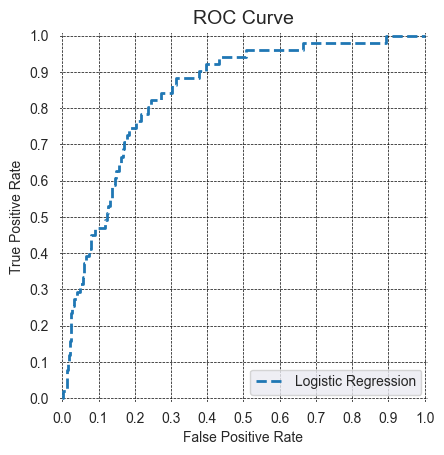

<Figure size 800x600 with 0 Axes>

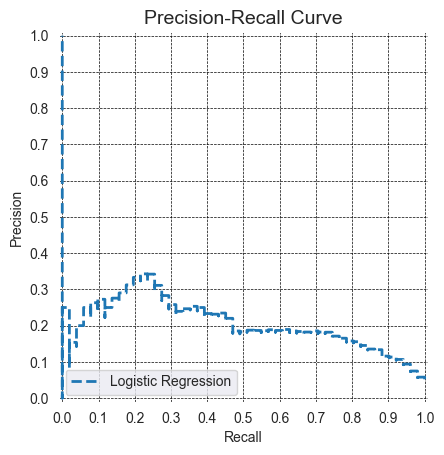

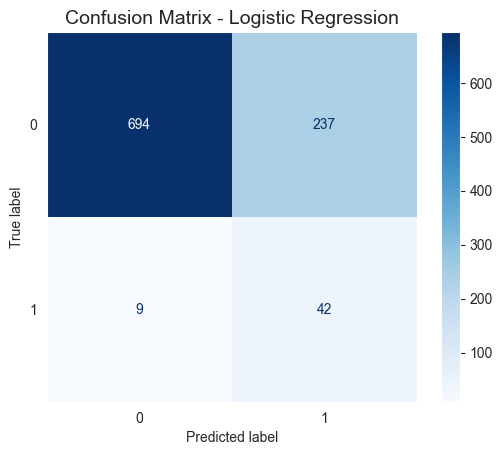

In [186]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

models = { "Logistic Regression": LR }

# --- ROC Curve ---
plt.figure(figsize=(8,6))
for name, model in models.items():
    disp = RocCurveDisplay.from_estimator(model, X_test, y_test)
    disp.line_.set_label(name)
    disp.line_.set_linestyle('--')
    disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("ROC Curve", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# --- Precision-Recall Curve ---
plt.figure(figsize=(8,6))
for name, model in models.items():
    pr_disp = PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    pr_disp.line_.set_label(name)
    pr_disp.line_.set_linestyle('--')
    pr_disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("Precision-Recall Curve", fontsize=14)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.show()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")   # nice blue color map

# Customize plot
plt.gca().set_facecolor("white")  # white background
plt.grid(False)                   # remove default grid
plt.title("Confusion Matrix - Logistic Regression", fontsize=14)
plt.show()

This one below is the one we will say is our best one. As a diagnostic tool, at least it gets nearly all the infected people. 1/6th of people predicted actually have it.

<Figure size 800x600 with 0 Axes>

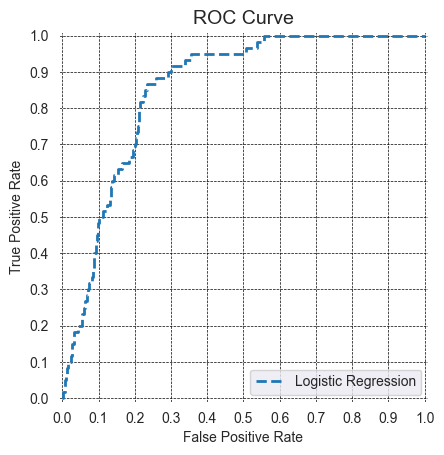

<Figure size 800x600 with 0 Axes>

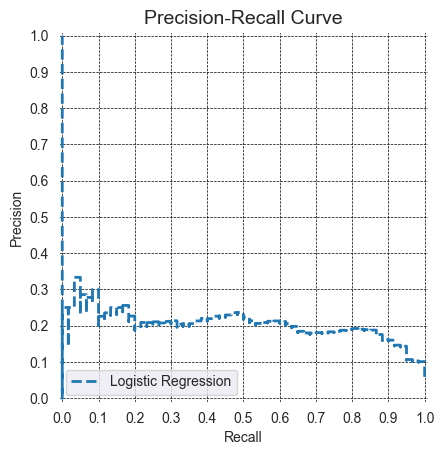

Accuracy: 0.7427
Precision: 0.1715
Recall: 0.8833
AUC: 0.8533


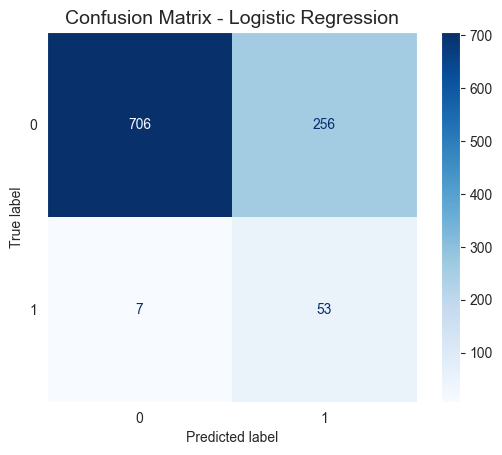

In [444]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

models = { "Logistic Regression": LR }

# --- ROC Curve ---
plt.figure(figsize=(8,6))
for name, model in models.items():
    disp = RocCurveDisplay.from_estimator(model, X_test, y_test)
    disp.line_.set_label(name)
    disp.line_.set_linestyle('--')
    disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("ROC Curve", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# --- Precision-Recall Curve ---
plt.figure(figsize=(8,6))
for name, model in models.items():
    pr_disp = PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    pr_disp.line_.set_label(name)
    pr_disp.line_.set_linestyle('--')
    pr_disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("Precision-Recall Curve", fontsize=14)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.show()

model = LR
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba > 0.5)

# --- Metrics ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUC: {auc:.4f}")

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")   # nice blue color map

# Customize plot
plt.gca().set_facecolor("white")  # white background
plt.grid(False)                   # remove default grid
plt.title("Confusion Matrix - Logistic Regression", fontsize=14)
plt.show()

**Tunning using GridSearch**

**Note: gridsearch is only applied on low preforming models**

## Random Forest 

**Training the Random Forest Classification model on the Training set**

In [42]:
RF= trainmodels(RandomForestClassifier(n_estimators = 10, criterion = 'entropy'),X_train, y_train)

Accuracy: 97.45 %


Predicting the Test set results 
[[1 1]
 [0 0]
 [0 0]
 ...
 [1 1]
 [1 1]
 [1 1]]

 Predicting for: 
  gender  age  hypertension  heart_disease ever_married work_type  \
0   Male   67             0              1          Yes   Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
 y_predicted :[1]


Making the Confusion Matrix
**************************
Accuracy: 97.45 %
[[921   9]
 [ 39 911]]


Accuracy repeort
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       930
           1       0.99      0.96      0.97       950

    accuracy                           0.97      1880
   macro avg       0.97      0.97      0.97      1880
weighted avg       0.97      0.97      0.97      1880



## Decision Tree Classification

**Training the Random Forest Classification model on the Training set**

In [43]:
parameters = {'max_leaf_nodes': list(range(2, 100)), 'min_samples_split': [2, 3, 4]}
DTC= trainmodels(DecisionTreeClassifier(criterion = 'entropy'),X_train,y_train)

Accuracy: 95.21 %


Predicting the Test set results 
[[1 1]
 [0 0]
 [0 0]
 ...
 [1 1]
 [1 1]
 [1 1]]

 Predicting for: 
  gender  age  hypertension  heart_disease ever_married work_type  \
0   Male   67             0              1          Yes   Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
 y_predicted :[1]


Making the Confusion Matrix
**************************
Accuracy: 95.21 %
[[877  53]
 [ 37 913]]


Accuracy repeort
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       930
           1       0.95      0.96      0.95       950

    accuracy                           0.95      1880
   macro avg       0.95      0.95      0.95      1880
weighted avg       0.95      0.95      0.95      1880



## Naive Bayes

**Training the Naive Bayes model on the Training set**

In [44]:
parameters = {'var_smoothing': np.logspace(0,-9, num=100)
}
NB =trainmodels(GaussianNB(),X_train,y_train) 

Accuracy: 63.09 %

MODELS RESULT IS BELOW 90% TUNNING WILL BE APPLIED 
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Accuracy: 72.23 %
Best Parameters: {'var_smoothing': 0.12328467394420659}

Predicting the Test set results 
[[1 1]
 [1 0]
 [0 0]
 ...
 [1 1]
 [1 1]
 [1 1]]

 Predicting for: 
  gender  age  hypertension  heart_disease ever_married work_type  \
0   Male   67             0              1          Yes   Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
 y_predicted :[1]


Making the Confusion Matrix
**************************
Accuracy: 63.09 %
[[237 693]
 [  1 949]]


Accuracy repeort
              precision    recall  f1-score   support

           0       1.00      0.25      0.41       930
           1       0.58      1.00      0.73       950

    accuracy                           0.63      1880
   macro avg       0.79      0.63      0.57      1880


**Tunning using GridSearch**

## K-Nearest Neighbors (K-NN)

**Training the K-NN model on the Training set**

In [257]:
parameters = {
    "n_neighbors": [3, 5, 7, 11],          # small set of neighbor counts
    "weights": ["uniform", "distance"],    # two main weighting schemes
    "metric": ["euclidean", "manhattan"],  # most common distance metrics
    "p": [1, 2],                           # only relevant for minkowski
    "algorithm": ["auto", "kd_tree"],      # faster options
    "leaf_size": [20, 30]                  # mid-range values
}
KNN = trainmodels(KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2),X_train,y_train)

Accuracy: 86.86 %
Precision: 13.89 %
Recall: 29.41 %
AUC: 59.71 %

MODELS RESULT IS BELOW 90% TUNNING WILL BE APPLIED 
{'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan'], 'p': [1, 2], 'algorithm': ['auto', 'kd_tree'], 'leaf_size': [20, 30]}
Fitting 10 folds for each of 128 candidates, totalling 1280 fits
Best Accuracy on Training: 97.48 %
Best Parameters: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}

Predicting the Test set results 
[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

 Predicting for: 
  gender  age  hypertension  heart_disease ever_married work_type  \
0   Male   67             0              1          Yes   Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
 y_predicted :[1]


Making the Confusion Matrix
**************************
Accuracy: 90.63 %
[[884  

In [267]:
gs_results_sorted = gs_results.sort_values(by='roc_auc', ascending=False).reset_index(inplace=False, drop=True)
gs_results_sorted

,algorithm,leaf_size,metric,n_neighbors,p,weights,accuracy,precision,recall,f1,roc_auc
0,auto,20,manhattan,3,1,distance,0.974788,0.953657,0.998143,0.975370,0.974786
1,kd_tree,30,manhattan,3,2,distance,0.974788,0.953657,0.998143,0.975370,0.974786
2,kd_tree,20,manhattan,3,1,distance,0.974788,0.953657,0.998143,0.975370,0.974786
3,kd_tree,20,manhattan,3,2,distance,0.974788,0.953657,0.998143,0.975370,0.974786
4,auto,30,manhattan,3,1,distance,0.974788,0.953657,0.998143,0.975370,0.974786
...,...,...,...,...,...,...,...,...,...,...,...
123,auto,30,euclidean,11,1,uniform,0.911363,0.859469,0.984080,0.917433,0.911358
124,auto,20,euclidean,11,2,uniform,0.911363,0.859469,0.984080,0.917433,0.911358
125,kd_tree,20,euclidean,11,2,uniform,0.911363,0.859469,0.984080,0.917433,0.911358
126,auto,30,euclidean,11,2,uniform,0.911363,0.859469,0.984080,0.917433,0.911358


In [264]:
# Define the KNN model with your parameters
KNN = KNeighborsClassifier(
    algorithm="auto",
    leaf_size=20,
    metric="manhattan",
    n_neighbors=3,
    p=1,
    weights="distance"
)
KNN.fit(X_train, y_train)

KNeighborsClassifier(leaf_size=20, metric='manhattan', n_neighbors=3, p=1,
                     weights='distance')

<Figure size 800x600 with 0 Axes>

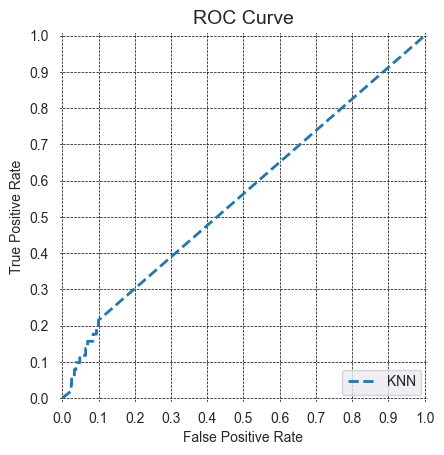

<Figure size 800x600 with 0 Axes>

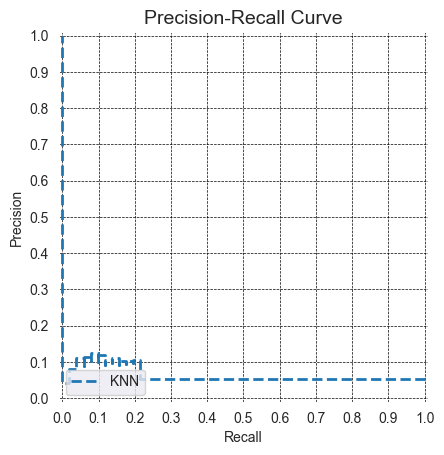

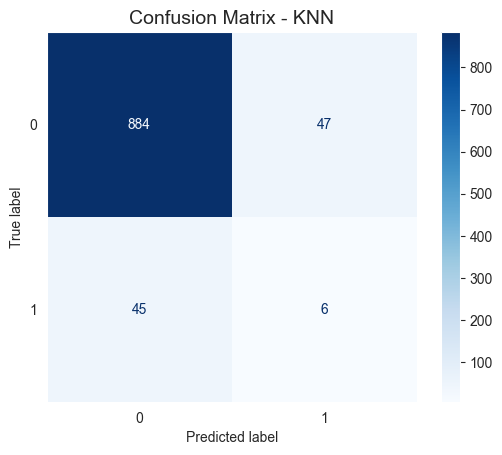

In [265]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

models = { "KNN" :KNN }

# --- ROC Curve ---
plt.figure(figsize=(8,6))
for name, model in models.items():
    disp = RocCurveDisplay.from_estimator(model, X_test, y_test)
    disp.line_.set_label(name)
    disp.line_.set_linestyle('--')
    disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("ROC Curve", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# --- Precision-Recall Curve ---
plt.figure(figsize=(8,6))
for name, model in models.items():
    pr_disp = PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    pr_disp.line_.set_label(name)
    pr_disp.line_.set_linestyle('--')
    pr_disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("Precision-Recall Curve", fontsize=14)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.show()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")   # nice blue color map

# Customize plot
plt.gca().set_facecolor("white")  # white background
plt.grid(False)                   # remove default grid
plt.title("Confusion Matrix - KNN", fontsize=14)
plt.show()

## Kernel SVM

**Training the Kernel SVM model on the Training set**

In [46]:
KSVM=trainmodels(SVC(kernel = 'rbf', random_state = 0), X_train,y_train)

Accuracy: 93.14 %


Predicting the Test set results 
[[1 1]
 [0 0]
 [0 0]
 ...
 [1 1]
 [1 1]
 [1 1]]

 Predicting for: 
  gender  age  hypertension  heart_disease ever_married work_type  \
0   Male   67             0              1          Yes   Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
 y_predicted :[1]


Making the Confusion Matrix
**************************
Accuracy: 93.14 %
[[883  47]
 [ 82 868]]


Accuracy repeort
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       930
           1       0.95      0.91      0.93       950

    accuracy                           0.93      1880
   macro avg       0.93      0.93      0.93      1880
weighted avg       0.93      0.93      0.93      1880



# Gradient boosting Classifications modeling

## Xgboost

### Training xgboost

In [248]:
parameters = {
    'learning_rate': [0.001, 0.01, 0.03, 0.05, 0.1, 0.3],   # same as eta
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.6, 0.5],
    'colsample_bytree': [0.8, 0.6, 0.5],
    'reg_lambda': [1, 5],   # L2 regularization
    'reg_alpha': [0, 1],    # L1 regularization
    'n_estimators': [100, 300]
}
XGB = trainmodels(XGBClassifier(),X_train,y_train)

Accuracy: 93.89 %
Precision: 9.09 %
Recall: 1.96 %
AUC: 50.44 %

MODELS RESULT IS BELOW 90% TUNNING WILL BE APPLIED 
{'learning_rate': [0.001, 0.01, 0.03, 0.05, 0.1, 0.3], 'max_depth': [3, 5, 7], 'subsample': [0.8, 0.6, 0.5], 'colsample_bytree': [0.8, 0.6, 0.5], 'reg_lambda': [1, 5], 'reg_alpha': [0, 1], 'n_estimators': [100, 300]}
Fitting 10 folds for each of 1296 candidates, totalling 12960 fits
Best Accuracy on Training: 97.56 %
Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}

Predicting the Test set results 
[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

 Predicting for: 
  gender  age  hypertension  heart_disease ever_married work_type  \
0   Male   67             0              1          Yes   Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
 y_predicted :[1]


Making the Co

In [249]:
gs_results_sorted = gs_results.sort_values(by='roc_auc', ascending=False).reset_index(inplace=False, drop=True)
gs_results_sorted

,colsample_bytree,learning_rate,max_depth,n_estimators,reg_alpha,reg_lambda,subsample,accuracy,precision,recall,f1,roc_auc
0,0.5,0.100,7,300,0,1,0.8,0.975594,0.991576,0.959680,0.971035,0.975594
1,0.8,0.300,5,300,0,5,0.8,0.975329,0.989776,0.961007,0.970993,0.975329
2,0.8,0.100,7,300,0,1,0.8,0.975195,0.989251,0.961272,0.970860,0.975195
3,0.6,0.100,7,300,0,1,0.8,0.975063,0.990015,0.960211,0.970582,0.975063
4,0.8,0.300,7,100,0,1,0.8,0.975062,0.989507,0.960741,0.970657,0.975062
...,...,...,...,...,...,...,...,...,...,...,...,...
1291,0.8,0.001,3,100,0,5,0.6,0.833736,0.791986,0.905268,0.844254,0.833742
1292,0.8,0.001,3,100,1,1,0.8,0.833602,0.791979,0.905000,0.844125,0.833608
1293,0.8,0.001,3,100,0,1,0.8,0.833204,0.790857,0.906062,0.844003,0.833210
1294,0.8,0.001,3,100,1,5,0.8,0.831743,0.790347,0.903143,0.842360,0.831750


Accuracy: 0.6839530332681018
Precision: 0.13370473537604458
Recall: 0.8
F1: 0.22911694510739858
ROC AUC: 0.7919265419265419


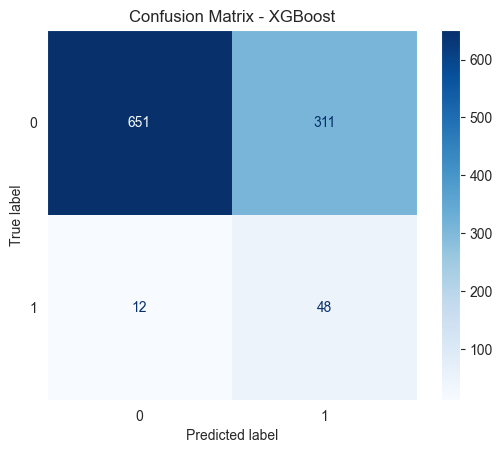

In [429]:
# Define the model with your parameters
xgb_model = XGBClassifier(
    colsample_bytree=0.5,
    learning_rate=0.1,
    max_depth=7,
    n_estimators=300,
    reg_alpha=0,
    reg_lambda=1,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric="logloss"  # avoids warning
)

# Fit the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.01) # We can change the threshold in order to change precision-recall

# Evaluate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC AUC:", roc_auc)

# Optional: plot it
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - XGBoost")
plt.show()

<Figure size 800x600 with 0 Axes>

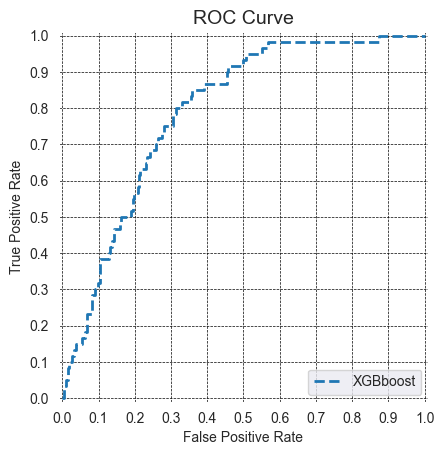

<Figure size 800x600 with 0 Axes>

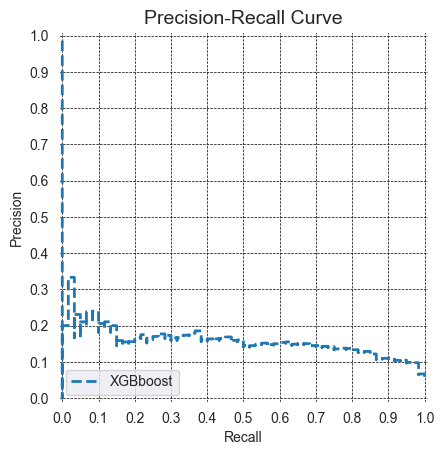

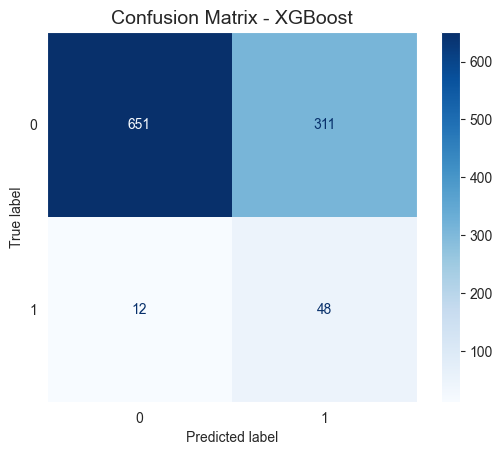

In [430]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

models = { "XGBboost" :xgb_model }

# --- ROC Curve ---
plt.figure(figsize=(8,6))
for name, model in models.items():
    disp = RocCurveDisplay.from_estimator(model, X_test, y_test)
    disp.line_.set_label(name)
    disp.line_.set_linestyle('--')
    disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("ROC Curve", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# --- Precision-Recall Curve ---
plt.figure(figsize=(8,6))
for name, model in models.items():
    pr_disp = PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    pr_disp.line_.set_label(name)
    pr_disp.line_.set_linestyle('--')
    pr_disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("Precision-Recall Curve", fontsize=14)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.show()

model.fit(X_train, y_train)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.01)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")   # nice blue color map

# Customize plot
plt.gca().set_facecolor("white")  # white background
plt.grid(False)                   # remove default grid
plt.title("Confusion Matrix - XGBoost", fontsize=14)
plt.show()

## CatBoost

###Training Catboots

In [49]:
CAT =trainmodels(CatBoostClassifier(),X_train, y_train)

Learning rate set to 0.02438
0:	learn: 0.6515001	total: 67.2ms	remaining: 1m 7s
1:	learn: 0.6251190	total: 69.8ms	remaining: 34.8s
2:	learn: 0.5928733	total: 72.2ms	remaining: 24s
3:	learn: 0.5665242	total: 74.6ms	remaining: 18.6s
4:	learn: 0.5483826	total: 77ms	remaining: 15.3s
5:	learn: 0.5295135	total: 79.9ms	remaining: 13.2s
6:	learn: 0.5079601	total: 82.6ms	remaining: 11.7s
7:	learn: 0.4893796	total: 85.3ms	remaining: 10.6s
8:	learn: 0.4679111	total: 87.7ms	remaining: 9.65s
9:	learn: 0.4457605	total: 90.5ms	remaining: 8.96s
10:	learn: 0.4284794	total: 92.8ms	remaining: 8.34s
11:	learn: 0.4154712	total: 95.9ms	remaining: 7.89s
12:	learn: 0.4063418	total: 98.6ms	remaining: 7.49s
13:	learn: 0.3911881	total: 101ms	remaining: 7.12s
14:	learn: 0.3785887	total: 104ms	remaining: 6.83s
15:	learn: 0.3679429	total: 107ms	remaining: 6.59s
16:	learn: 0.3611088	total: 110ms	remaining: 6.38s
17:	learn: 0.3482854	total: 113ms	remaining: 6.19s
18:	learn: 0.3405101	total: 116ms	remaining: 5.98s
19:

162:	learn: 0.0954161	total: 501ms	remaining: 2.57s
163:	learn: 0.0952468	total: 503ms	remaining: 2.56s
164:	learn: 0.0950581	total: 505ms	remaining: 2.56s
165:	learn: 0.0949001	total: 508ms	remaining: 2.55s
166:	learn: 0.0946780	total: 510ms	remaining: 2.54s
167:	learn: 0.0944227	total: 513ms	remaining: 2.54s
168:	learn: 0.0940979	total: 516ms	remaining: 2.54s
169:	learn: 0.0937941	total: 518ms	remaining: 2.53s
170:	learn: 0.0936813	total: 521ms	remaining: 2.52s
171:	learn: 0.0934960	total: 524ms	remaining: 2.52s
172:	learn: 0.0932256	total: 526ms	remaining: 2.52s
173:	learn: 0.0930647	total: 529ms	remaining: 2.51s
174:	learn: 0.0927119	total: 531ms	remaining: 2.5s
175:	learn: 0.0924837	total: 534ms	remaining: 2.5s
176:	learn: 0.0921950	total: 537ms	remaining: 2.49s
177:	learn: 0.0918941	total: 540ms	remaining: 2.49s
178:	learn: 0.0917410	total: 542ms	remaining: 2.48s
179:	learn: 0.0915558	total: 545ms	remaining: 2.48s
180:	learn: 0.0913630	total: 548ms	remaining: 2.48s
181:	learn: 0.

339:	learn: 0.0705133	total: 972ms	remaining: 1.89s
340:	learn: 0.0703983	total: 974ms	remaining: 1.88s
341:	learn: 0.0703435	total: 977ms	remaining: 1.88s
342:	learn: 0.0702758	total: 980ms	remaining: 1.88s
343:	learn: 0.0702080	total: 983ms	remaining: 1.87s
344:	learn: 0.0701407	total: 986ms	remaining: 1.87s
345:	learn: 0.0700204	total: 988ms	remaining: 1.87s
346:	learn: 0.0699486	total: 991ms	remaining: 1.86s
347:	learn: 0.0698113	total: 993ms	remaining: 1.86s
348:	learn: 0.0697571	total: 995ms	remaining: 1.86s
349:	learn: 0.0697176	total: 998ms	remaining: 1.85s
350:	learn: 0.0695959	total: 1s	remaining: 1.85s
351:	learn: 0.0695094	total: 1s	remaining: 1.85s
352:	learn: 0.0694012	total: 1s	remaining: 1.84s
353:	learn: 0.0692928	total: 1.01s	remaining: 1.84s
354:	learn: 0.0692228	total: 1.01s	remaining: 1.84s
355:	learn: 0.0690759	total: 1.01s	remaining: 1.83s
356:	learn: 0.0689594	total: 1.01s	remaining: 1.83s
357:	learn: 0.0688531	total: 1.02s	remaining: 1.83s
358:	learn: 0.0687721

530:	learn: 0.0560242	total: 1.48s	remaining: 1.31s
531:	learn: 0.0559892	total: 1.49s	remaining: 1.31s
532:	learn: 0.0559294	total: 1.49s	remaining: 1.3s
533:	learn: 0.0558558	total: 1.49s	remaining: 1.3s
534:	learn: 0.0558133	total: 1.5s	remaining: 1.3s
535:	learn: 0.0557497	total: 1.5s	remaining: 1.3s
536:	learn: 0.0556386	total: 1.5s	remaining: 1.29s
537:	learn: 0.0555984	total: 1.51s	remaining: 1.29s
538:	learn: 0.0555457	total: 1.51s	remaining: 1.29s
539:	learn: 0.0554940	total: 1.51s	remaining: 1.29s
540:	learn: 0.0554485	total: 1.51s	remaining: 1.28s
541:	learn: 0.0553876	total: 1.52s	remaining: 1.28s
542:	learn: 0.0553708	total: 1.52s	remaining: 1.28s
543:	learn: 0.0552514	total: 1.52s	remaining: 1.28s
544:	learn: 0.0551583	total: 1.52s	remaining: 1.27s
545:	learn: 0.0550958	total: 1.53s	remaining: 1.27s
546:	learn: 0.0550276	total: 1.53s	remaining: 1.27s
547:	learn: 0.0549760	total: 1.53s	remaining: 1.26s
548:	learn: 0.0549423	total: 1.54s	remaining: 1.26s
549:	learn: 0.05490

698:	learn: 0.0471592	total: 1.95s	remaining: 839ms
699:	learn: 0.0470983	total: 1.95s	remaining: 837ms
700:	learn: 0.0470520	total: 1.95s	remaining: 834ms
701:	learn: 0.0470313	total: 1.96s	remaining: 831ms
702:	learn: 0.0469892	total: 1.96s	remaining: 828ms
703:	learn: 0.0469517	total: 1.96s	remaining: 826ms
704:	learn: 0.0468815	total: 1.97s	remaining: 823ms
705:	learn: 0.0468603	total: 1.97s	remaining: 821ms
706:	learn: 0.0467937	total: 1.97s	remaining: 818ms
707:	learn: 0.0467434	total: 1.98s	remaining: 815ms
708:	learn: 0.0466801	total: 1.98s	remaining: 812ms
709:	learn: 0.0466329	total: 1.98s	remaining: 810ms
710:	learn: 0.0466095	total: 1.99s	remaining: 807ms
711:	learn: 0.0465460	total: 1.99s	remaining: 804ms
712:	learn: 0.0465038	total: 1.99s	remaining: 802ms
713:	learn: 0.0464752	total: 1.99s	remaining: 799ms
714:	learn: 0.0464632	total: 2s	remaining: 796ms
715:	learn: 0.0464339	total: 2s	remaining: 794ms
716:	learn: 0.0464048	total: 2s	remaining: 791ms
717:	learn: 0.0463159

888:	learn: 0.0389108	total: 2.47s	remaining: 308ms
889:	learn: 0.0388618	total: 2.47s	remaining: 305ms
890:	learn: 0.0388270	total: 2.47s	remaining: 303ms
891:	learn: 0.0387483	total: 2.48s	remaining: 300ms
892:	learn: 0.0387424	total: 2.48s	remaining: 297ms
893:	learn: 0.0386955	total: 2.48s	remaining: 294ms
894:	learn: 0.0386672	total: 2.48s	remaining: 291ms
895:	learn: 0.0385930	total: 2.49s	remaining: 289ms
896:	learn: 0.0385647	total: 2.49s	remaining: 286ms
897:	learn: 0.0385579	total: 2.49s	remaining: 283ms
898:	learn: 0.0385342	total: 2.5s	remaining: 280ms
899:	learn: 0.0384886	total: 2.5s	remaining: 278ms
900:	learn: 0.0384531	total: 2.5s	remaining: 275ms
901:	learn: 0.0383946	total: 2.5s	remaining: 272ms
902:	learn: 0.0383507	total: 2.5s	remaining: 269ms
903:	learn: 0.0383081	total: 2.51s	remaining: 266ms
904:	learn: 0.0382728	total: 2.51s	remaining: 264ms
905:	learn: 0.0382025	total: 2.51s	remaining: 261ms
906:	learn: 0.0381884	total: 2.52s	remaining: 258ms
907:	learn: 0.038

**Predicting the Test set results**

---




# Deep Learning Classifications Modeling

In [340]:
import tensorflow as tf
from tensorflow.keras import metrics
from tensorflow.keras import layers, regularizers, metrics

## Artificial Neural Network

### Initialising the ANN

In [425]:
# ann = tf.keras.models.Sequential()
# ann.add(tf.keras.layers.Dense(units=32, activation='relu'))
# ann.add(tf.keras.layers.Dense(units=32, activation='relu'))
# ann.add(tf.keras.layers.Dense(units=16, activation='relu'))
# ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
ann = tf.keras.models.Sequential([
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

opt = tf.keras.optimizers.Adam(learning_rate=0.005)
ann.compile(optimizer = opt, loss = 'binary_crossentropy', metrics = ['accuracy',metrics.AUC()])

ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 487us/step - accuracy: 0.7407 - auc_5: 0.8178 - loss: 0.5396
Epoch 2/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.8371 - auc_5: 0.9134 - loss: 0.3966
Epoch 3/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.8462 - auc_5: 0.9232 - loss: 0.3769
Epoch 4/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.8537 - auc_5: 0.9329 - loss: 0.3546
Epoch 5/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - accuracy: 0.8589 - auc_5: 0.9359 - loss: 0.3470
Epoch 6/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - accuracy: 0.8646 - auc_5: 0.9420 - loss: 0.3333
Epoch 7/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - accuracy: 0.8716 - auc_5: 0.9463 - loss: 0.3233
Epoch 8/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - accuracy: 0.8771 - auc_5: 0.9478 - loss: 0.3198
Epoch 9/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - accuracy: 0.8817 - auc_5: 0.9510 - loss: 0.3113
Epoch 10/100
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step

## **Predicting the Test set**

In [335]:
X_test3 = X_test
y_test3 = y_test

In [337]:
sm = SMOTE()
X_test, y_test = sm.fit_resample(X_test, y_test)

In [345]:
X_test = X_test3
y_test = y_test3

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step
[[0 0]
 [0 0]
 [1 0]
 ...
 [0 0]
 [0 0]
 [0 0]]
Accuracy: 0.7006
Precision: 0.1227
Recall: 0.6667
AUC: 0.6847


<Figure size 800x600 with 0 Axes>

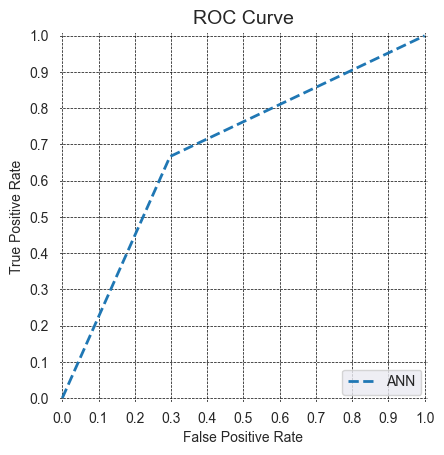

<Figure size 800x600 with 0 Axes>

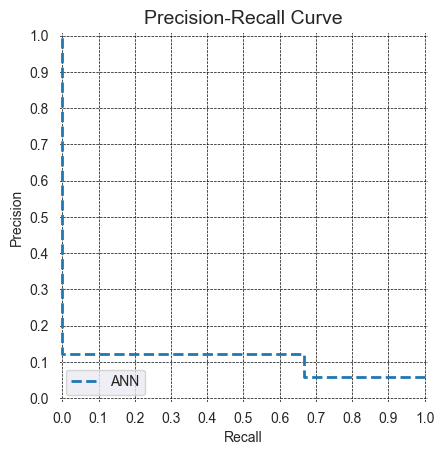

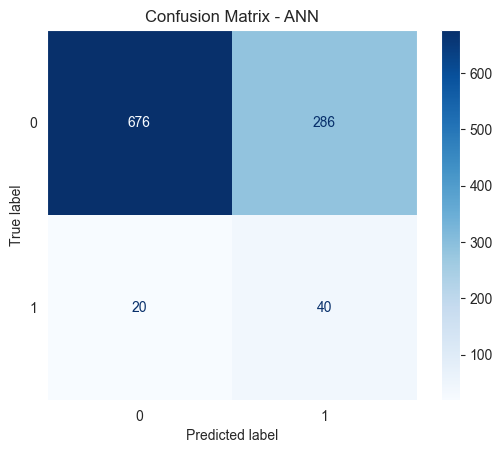

In [428]:
y_pred_ann = ann.predict(X_test)
y_pred_ann = (y_pred_ann > 0.1)
print(np.concatenate((y_pred_ann.reshape(len(y_pred_ann),1), y_test.reshape(len(y_test),1)),1))
# --- Metrics ---
accuracy = accuracy_score(y_test, y_pred_ann)
precision = precision_score(y_test, y_pred_ann)
recall = recall_score(y_test, y_pred_ann)
auc = roc_auc_score(y_test, y_pred_ann)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUC: {auc:.4f}")

# --- ROC Curve ---
plt.figure(figsize=(8,6))
roc_disp = RocCurveDisplay.from_predictions(y_test, y_pred_ann.ravel())
roc_disp.line_.set_label("ANN")
roc_disp.line_.set_linestyle('--')
roc_disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("ROC Curve", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# --- Precision-Recall Curve ---
plt.figure(figsize=(8,6))
pr_disp = PrecisionRecallDisplay.from_predictions(y_test, y_pred_ann.ravel())
pr_disp.line_.set_label("ANN")
pr_disp.line_.set_linestyle('--')
pr_disp.line_.set_linewidth(2)

plt.gca().set_facecolor("white")
plt.grid(True, color="black", linestyle="--", linewidth=0.5)
plt.xticks([i/10 for i in range(11)])
plt.yticks([i/10 for i in range(11)])
plt.title("Precision-Recall Curve", fontsize=14)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_ann)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - ANN")
plt.show()

### Making the Confusion Matrix

[[752 179]
 [ 31  20]]
0.7861507128309573


Text(0.5, 1.0, 'Artificial Neural Network')

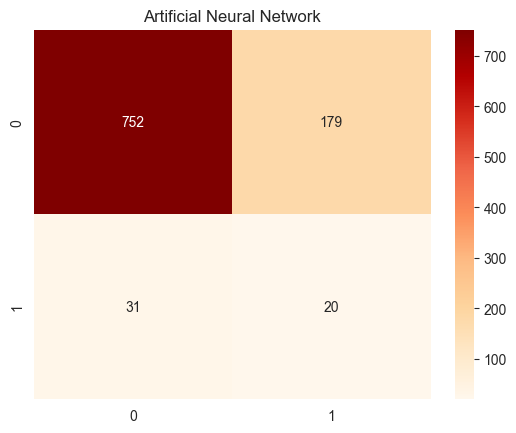

In [304]:
cm = confusion_matrix(y_test, y_pred_ann)
print(cm)
accuracy_score(y_test, y_pred_ann)
ann_report=classification_report(y_test, y_pred_ann)
print(accuracy_score(y_test, y_pred_ann))
sns.heatmap(confusion_matrix(y_test, y_pred_ann),annot=True,cmap='OrRd', fmt='g' )
plt.title('Artificial Neural Network')

In [ ]:
print(ann_report)

# Dictionary of Trained Models 

In [ ]:
models = { "Logistic Regression":LR, " Random Forest":RF, "Decision Tree Classification":DTC,
        "Naive Bayes":NB ,"K-Nearest Neighbors (K-NN)":KNN,"Kernel SVM":KSVM,
       "XGBboots" :XGB, "Catboost": CAT }
        

# Applying k-Fold Cross Validation on all models 

In [ ]:
for names,model, in models.items():
  print(f" Cross validation results {names}")
  k_fold_cross_validation(model,X_train,y_train,15)
  print()

# Evaluating and visualise results.

In [ ]:
for names,model, in models.items():
  RocCurveDisplay.from_estimator(model, X_test, y_test)
  # plot_roc_curve(model, X_test, y_test)
  plt.title(names)

In [ ]:
for names,model, in models.items():
  plt.title(names)
  plot_confusion_matrix(model)
  